# Teste de hipótese T para uma amostra

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# dataset dos engenheiros entrevistados
df = pd.read_csv('SalariosEng.csv')
df.head(10)

,Entrevistado,Salário Informado
0,x1,10954.0
1,x2,11323.0
2,x3,7717.0
3,x4,8424.0
4,x5,11317.0
5,x6,7823.0
6,x7,11895.0
7,x8,11131.0
8,x9,9214.0
9,x10,9992.0


In [3]:
print(df.shape)

(100, 2)


In [4]:
# Transformando os dados
df['Salário Informado'] = pd.to_numeric(df['Salário Informado'])

In [5]:
df.dtypes

Entrevistado          object
Salário Informado    float64
dtype: object

# Verificando a normalidade populacional (grupo controle)

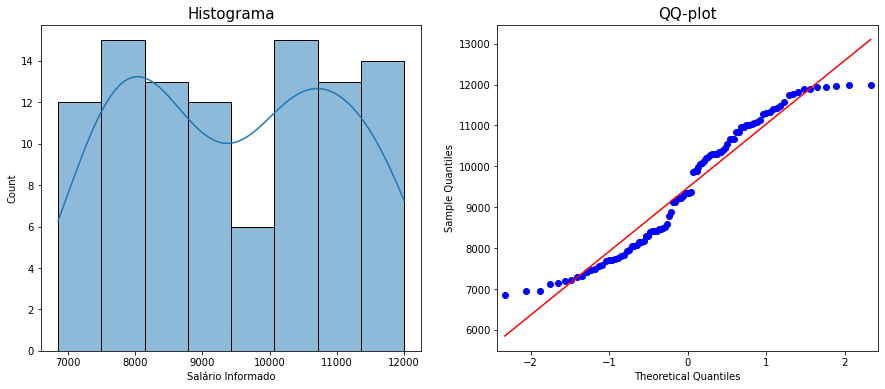

In [6]:
#histograma e qq plot
import statsmodels.api as sm

fig, ax = plt.subplots(1, 2, figsize=(15,6))

sns.histplot(df['Salário Informado'], kde=True, ax=ax[0])
ax[0].set_title('Histograma', fontsize=15)

sm.ProbPlot(df['Salário Informado']).qqplot(line='s', ax=ax[1])
ax[1].set_title('QQ-plot', fontsize=15)

plt.show()

## Aplicando o teste de normalidade

In [7]:
# aplicando o teste estatístico shapiro wilK

from scipy.stats import shapiro

statistic, p_value = shapiro(df['Salário Informado'])
print(statistic, p_value)
if(p_value <= 0.05):
    print('Distribuição não normal')
else:
    print('É uma distribuição normal!')

0.9381125569343567 0.00014817631745245308
Distribuição não normal


# Extraindo uma amostra da população

In [8]:
# Selecionando uma amostra aleatória com 40 individuos da população

salarios = df['Salário Informado'].sort_values()

import random
samp_salario = random.sample(list(salarios), 40)  

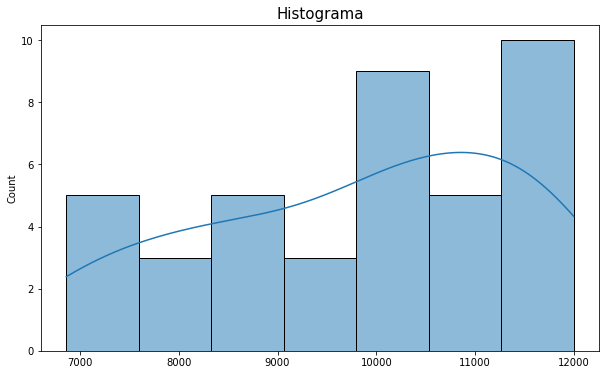

In [9]:
# Verificando a normalidade da amostra
import statsmodels.api as sm

fig, ax = plt.subplots(figsize=(10,6))

sns.histplot(samp_salario, kde=True)
ax.set_title('Histograma', fontsize=15)

plt.show()

In [10]:
# aplicando o teste estatístico shapiro wilK

from scipy.stats import shapiro

statistic, p_value = shapiro(samp_salario)
print(statistic, p_value)
if(p_value <= 0.05):
    print('Distribuição não normal')
else:
    print('É uma distribuição normal!')

0.9334079623222351 0.020838001742959023
Distribuição não normal


## Obtendo as estatísticas da população

In [11]:
salario_describe = df['Salário Informado'].describe().round(2).reset_index()
salario_describe.columns = ['Estatística', 'Salário']
salario_describe

,Estatística,Salário
0,count,100.00
1,mean,9477.20
2,std,1564.51
3,min,6862.00
4,25%,8065.75
5,50%,9343.50
6,75%,10872.25
7,max,11999.00


## Obtendo as estatísticas da amostra

In [12]:
count = len(samp_salario)
mean = np.mean(samp_salario)
median = np.median(samp_salario)
stand = np.std(samp_salario)
_min = np.min(samp_salario)
q25 = np.quantile(samp_salario, 0.25)
q50 = np.quantile(samp_salario, 0.5)
q75 = np.quantile(samp_salario, 0.75)
_max = np.max(samp_salario)

describe = pd.DataFrame({'Estatística_amostral' : ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max'], 
                         'Salário' : [count, mean, stand, _min, q25, q50, q75, _max]})

describe

,Estatística_amostral,Salário
0,count,40.000000
1,mean,9815.575000
2,std,1581.170814
3,min,6862.000000
4,25%,8498.250000
5,50%,10061.500000
6,75%,11177.500000
7,max,11995.000000


## Escolha do teste de hipótese mais adequado

### Hipótese nula H0:  a média Salarial do Engenheiro no Brasil é aproximadadmente 9.477,20 reais
### Hipótese alternativa H1: a média Salarial do Engenheiro é menos de 9.477,20 reais

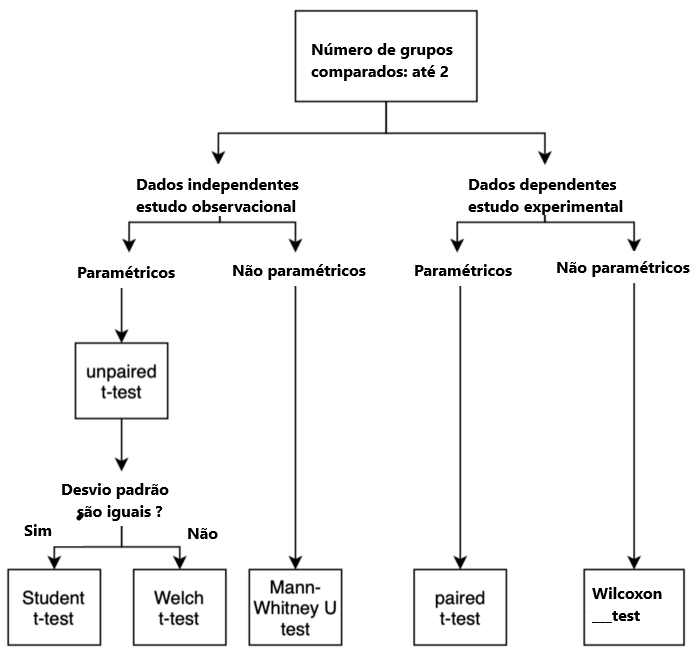

In [13]:
from IPython.display import Image
Image(filename='teste_hip.png', width=700, height=800)

### O teste mais apropriado para este caso é o Mann Whitney U test

In [14]:
# aplicando o teste Whitney U

from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(samp_salario, df['Salário Informado'], alternative='less')

print('Estatística de teste: %.2f' %(stat.round(2)))
print('P-Valor: %.2f' %(p.round(2)))

print('\nResultado:')
if p > 0.05:
    print('A média salarial é aproximadamente R$ 9.477,20')
else:
    print('A média salarial é menor do que R$ 9.477,20')

Estatística de teste: 2252.00
P-Valor: 0.88

Resultado:
A média salarial é aproximadamente R$ 9.477,20


## Conclusão : A hipótese proposta nula não pode ser rejeitada

### Rejeita se p-Valor <= 0,05

### ou rejeita se p-Valor <= 0,01 (casos mais sérios)